# Load the dataset & look at it first


In [23]:

import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\Housing.csv")
# First look at the data
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [24]:
print("\nColumn info:")
print(df.info())



Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [26]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [27]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


# Check categorical column values

In [28]:
print("mainroad:", df['mainroad'].unique())
print("guestroom:", df['guestroom'].unique())
print("basement:", df['basement'].unique())
print("hotwaterheating:", df['hotwaterheating'].unique())
print("airconditioning:", df['airconditioning'].unique())
print("prefarea:", df['prefarea'].unique())
print("furnishingstatus:", df['furnishingstatus'].unique())

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


#  Data preprocessing & cleaning

In [29]:
# Encode all Yes/No columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus (3 categories, no natural order)
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("New shape:", df.shape)
df.head()

New shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [30]:
print(df.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


# Split features (X) and target (y), then train/test split

In [33]:
from sklearn.model_selection import train_test_split

# X = all features except price
X = df.drop('price', axis=1)

# y = target variable
y = df['price']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (436, 13)
Testing set size: (109, 13)


# Train the Linear Regression model

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
print(coefficients)
print("\nIntercept:", model.intercept_)

Model trained successfully!
                            Feature   Coefficient
0                              area  2.359688e+02
1                          bedrooms  7.677870e+04
2                         bathrooms  1.094445e+06
3                           stories  4.074766e+05
4                          mainroad  3.679199e+05
5                         guestroom  2.316100e+05
6                          basement  3.902512e+05
7                   hotwaterheating  6.846499e+05
8                   airconditioning  7.914267e+05
9                           parking  2.248419e+05
10                         prefarea  6.298906e+05
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05

Intercept: 260032.35760741495


 # Predict on test data & evaluate accuracy

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

accuracy_percentage = 100 - (mae / y_test.mean() * 100)
print(f"\nAverage prediction accuracy: {accuracy_percentage:.2f}%")

Model Evaluation:
Mean Absolute Error (MAE): 970,043.40
Mean Squared Error (MSE): 1,754,318,687,330.66
Root Mean Squared Error (RMSE): 1,324,506.96
R² Score: 0.6529

Average prediction accuracy: 80.63%


# Visualize predictions vs actual (makes the "weak relationship" visible)

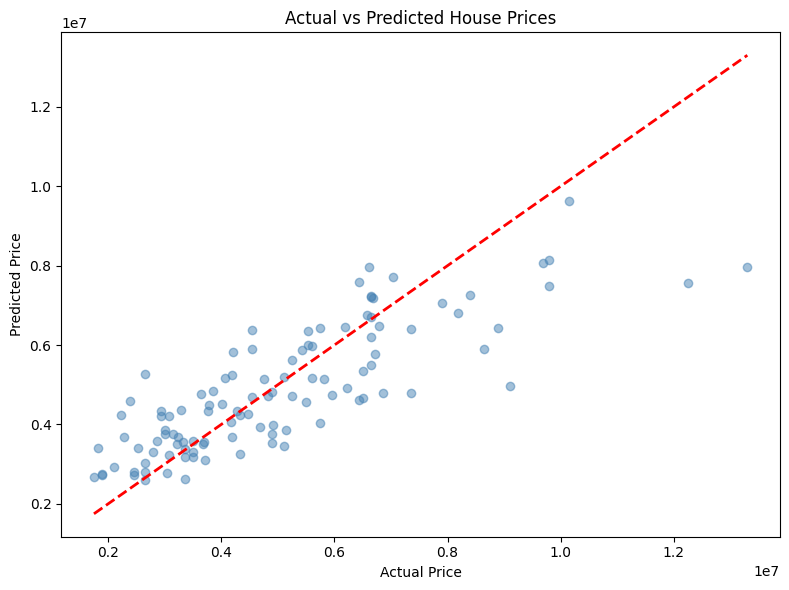

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

# A function to predict price from new input features (this fulfills "predict house prices based on input features")

In [37]:
def predict_house_price(area, bedrooms, bathrooms, stories, mainroad, guestroom, 
                          basement, hotwaterheating, airconditioning, parking, 
                          prefarea, furnishingstatus):
    """
    mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea: 'yes' or 'no'
    furnishingstatus: 'furnished', 'semi-furnished', or 'unfurnished'
    """
    binary_map = {'yes': 1, 'no': 0}
    
    semi_furnished = 1 if furnishingstatus == 'semi-furnished' else 0
    unfurnished = 1 if furnishingstatus == 'unfurnished' else 0

    input_data = pd.DataFrame([{
        'area': area,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'stories': stories,
        'mainroad': binary_map[mainroad],
        'guestroom': binary_map[guestroom],
        'basement': binary_map[basement],
        'hotwaterheating': binary_map[hotwaterheating],
        'airconditioning': binary_map[airconditioning],
        'parking': parking,
        'prefarea': binary_map[prefarea],
        'furnishingstatus_semi-furnished': semi_furnished,
        'furnishingstatus_unfurnished': unfurnished
    }])

    predicted_price = model.predict(input_data)[0]
    return predicted_price

# Example usage
price = predict_house_price(
    area=6000, bedrooms=3, bathrooms=2, stories=2,
    mainroad='yes', guestroom='no', basement='yes',
    hotwaterheating='no', airconditioning='yes', parking=2,
    prefarea='yes', furnishingstatus='furnished'
)
print(f"Predicted Price: {price:,.2f}")

Predicted Price: 7,539,196.30


# Accuracy 

In [40]:
# Accuracy-style metric: average % how close predictions are to actual prices
accuracy_percentage = 100 - (mae / y_test.mean() * 100)
print(f"Average prediction accuracy: {accuracy_percentage:.2f}%")

Average prediction accuracy: 80.63%
